Importar as bibliotecas necessárias

In [117]:
import timeit # Para medir o tempo de execução
import optuna # Para otimização de hiperparâmetros
start_time = timeit.default_timer() # Marcar o início do tempo
import torch
import torchvision.transforms as transforms
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import torch.optim as optim
import numpy as np
from torchvision.utils import save_image
import matplotlib.pyplot as plt
# Definir o dispositivo (cuda se disponível, caso contrário CPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)
from scipy.stats import wasserstein_distance

import mplhep as hep
plt.style.use("default")
plt.style.use(hep.style.CMS)
plt.rcParams['font.size'] = 12 

cuda


In [118]:
def normalize(data):
    return ((data - means) / stds).to(device)

def denormalize(data):
    return (data * stds + means).to(device)


In [119]:
def mass_func(data):
    data = torch.transpose(data, 0, 1)
    
    px = data[0] + data[1]
    py = data[2] + data[3]
    pz = data[4] + data[5]
    E = data[6] + data[7]

    m = (E**2 - px**2 - py**2 - pz**2)
    return m

O próximo passo é carregar os dados de entrada. Os dados utilizados são valores de momento transversal dos píons e dos káons, partículas filha do méson D0. Inicialmente, os dados se encontram em um .txt, e devem ser transformados em um tensor no PyTorch. Além disso, os dados são normalizados para aumentar a estabilidade do treino e divididos em set de treino, validação e teste.

In [120]:
# Carregar os dados de entrada
data = np.loadtxt("data_D0_daughtersPx_Py_Pz_E_trk1_trk2.txt")
D0_data = np.loadtxt("data_D0_daughtersPx_Py_Pz_E_D0.txt")
tensor_data = torch.tensor(data, dtype=torch.float32, device=device)
D0_data = torch.tensor(D0_data, dtype=torch.float32, device=device)
nVar = tensor_data.shape[1]
mass_D0 = 1.8648


print(f"Shape do tensor: {tensor_data.shape}")
print(f"Raw {tensor_data.size()}, {type(tensor_data)}")
print(f"Dados do crus: {tensor_data}")
print(f"Número de variáveis de entrada: {nVar}")

# Divisão dos dados em treino, validação e teste
nTotal = tensor_data.size(0)
nTrain = int(0.6 * nTotal)
nVal = int(0.2 * nTotal)
nTest = nTotal - nTrain - nVal
print(f"nTrain: {nTrain}, nVal: {nVal}, nTest: {nTest}")

x_train = tensor_data[:nTrain]
x_val   = tensor_data[nTrain:nTrain + nVal]
x_test  = tensor_data[nTrain + nVal:]

print(f"x_train: {x_train.size()}, x_val: {x_val.size()}, x_test: {x_test.size()}")

#_Calculating statistics to normalize data
means = x_train.mean(dim=0)  # shape [nVar]
stds  = x_train.std(dim=0)


# DataLoaders
batch_size = 32
trainloader = DataLoader(TensorDataset(x_train), shuffle=True,  batch_size=batch_size)
valloader   = DataLoader(TensorDataset(x_val),   shuffle=False, batch_size=batch_size)
testloader  = DataLoader(TensorDataset(x_test),  shuffle=False, batch_size=batch_size)


Shape do tensor: torch.Size([20000, 8])
Raw torch.Size([20000, 8]), <class 'torch.Tensor'>
Dados do crus: tensor([[ -0.1366,   2.0796,  -0.5123,  ...,  -2.2954,   0.7437,   3.7436],
        [ -1.7234,   0.1727,  -1.7169,  ...,   1.3204,   3.6637,   2.0659],
        [  1.5444,   1.7190,   0.1174,  ..., -10.7713,   4.3586,  10.9472],
        ...,
        [ -0.2093,   0.8172,  -2.9004,  ...,   0.9550,   3.3812,   1.3934],
        [ -0.6546,  -1.0264,  -0.0698,  ...,   0.2606,   0.9285,   2.1903],
        [  1.4160,   0.2751,   2.3829,  ...,  -0.0613,   5.6575,   0.6417]],
       device='cuda:0')
Número de variáveis de entrada: 8
nTrain: 12000, nVal: 4000, nTest: 4000
x_train: torch.Size([12000, 8]), x_val: torch.Size([4000, 8]), x_test: torch.Size([4000, 8])


In [121]:
def covariance_penalty(recon_x, x):
    # Centralizar
    recon_centered = recon_x - recon_x.mean(dim=0)
    x_centered = x - x.mean(dim=0)
    
    # Matrizes de covariância (8x8)
    N = x.shape[0]
    cov_recon = (recon_centered.T @ recon_centered) / N
    cov_real  = (x_centered.T @ x_centered) / N
    
    # Penalizar diferença
    return F.mse_loss(cov_recon, cov_real, reduction='mean')

Construção do VAE. A arquitetura é genérica (tamanho e número de camadas serão otimizados).

A loss function combina a divergência KL com o erro de reconstrução (MSE).

In [122]:
class VAE(nn.Module):
    def __init__(self, nVar, h_dims, z_dim, activation):
        super(VAE, self).__init__()
        self.activation = activation

        # Encoder
        encoder_layers = []
        input_dim = nVar
        for h_dim in h_dims:
            encoder_layers.append(nn.Linear(input_dim, h_dim))
            encoder_layers.append(self.activation)
            input_dim = h_dim
        self.encoder_layers = nn.Sequential(*encoder_layers)
        self.fc21 = nn.Linear(h_dims[-1], z_dim)
        self.fc22 = nn.Linear(h_dims[-1], z_dim)

        # Decoder
        decoder_layers = []
        input_dim = z_dim
        for h_dim in reversed(h_dims):
            decoder_layers.append(nn.Linear(input_dim, h_dim))
            decoder_layers.append(self.activation)
            input_dim = h_dim
        self.decoder_layers = nn.Sequential(*decoder_layers)
        self.fc3 = nn.Linear(h_dims[0], nVar)

    def encoder(self, x):
        h = self.encoder_layers(x)
        return self.fc21(h), self.fc22(h)

    def sampling(self, mu, log_var):
        std = torch.exp(0.5 * log_var)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decoder(self, z):
        h = self.decoder_layers(z)
        return self.fc3(h)

    def forward(self, x):
        mu, log_var = self.encoder(x)
        z = self.sampling(mu, log_var)
        return self.decoder(z), mu, log_var

def loss_function(recon_x, x, D0, mu, log_var, beta, lambda_cov):
    # Evaluate masses
    #d_recon_x = denormalize(recon_x)
    #reco_mass2 = mass_func(d_recon_x)

    # KL divergence

    # Penalidade de covariância — preserva correlações 2D
    cov_pen = covariance_penalty(recon_x, x)

    KLD = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp())
    # Reconstruction loss (MSE)
    MSE = F.mse_loss(recon_x, x, reduction='sum')

    return beta * MSE + (1 - beta) * KLD + lambda_cov * cov_pen, MSE, KLD, cov_pen


Treinamento e validação do modelo. Early stopping é aplicado caso a perda de validação não melhore.

In [123]:
def train(model, trainloader, optimizer, beta, lambda_cov):
    model.train()
    train_loss = 0
    total_mse = 0
    total_kld = 0
    total_cov = 0
    
    for i in trainloader:
        data = i[0].to(device).float()
        D0s = data  
        data = normalize(data)
        
        optimizer.zero_grad()
        recon_batch, mu, log_var = model(data)
        
        # A loss_function retorna os valores do batch atual
        loss, mse, kld, cov_pen = loss_function(recon_batch, data, D0s, mu, log_var, beta, lambda_cov)
        
        loss.backward()
        optimizer.step()
        
        # Acumulando os valores (usando .item() para não pesar a memória da GPU)
        train_loss += loss.item()
        total_mse += mse.item()
        total_kld += kld.item()
        total_cov += cov_pen.item()

    # Número de iterações (batches) nesta época
    num_batches = len(trainloader)
    
    # Retornamos a média aritmética de todos os batches
    return (train_loss / num_batches, 
            total_mse / num_batches, 
            total_kld / num_batches, 
            total_cov / num_batches)

def validate(model, valloader, beta, lambda_cov):
    model.eval()
    val_loss = 0
    total_mse = 0
    total_kld = 0
    total_cov = 0
    
    with torch.no_grad():
        for i in valloader:
            data = i[0].to(device).float()
            D0s = data
            data = normalize(data)
            
            recon_batch, mu, log_var = model(data)
            
            # loss para o batch atual
            loss, mse, kld, cov_pen = loss_function(recon_batch, data, D0s, mu, log_var, beta, lambda_cov)
            
            # Acumuladores
            val_loss += loss.item()
            total_mse += mse.item()
            total_kld += kld.item()
            total_cov += cov_pen.item()

    # Número de iterações (batches) para tirar a média
    num_batches = len(valloader)
    
    return (val_loss / num_batches, 
            total_mse / num_batches, 
            total_kld / num_batches, 
            total_cov / num_batches)

class EarlyStopping:
    def __init__(self, patience=10, min_delta=0):
        self.patience = patience
        self.min_delta = min_delta
        self.best_loss = None
        self.counter = 0

    def __call__(self, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
            return False
        elif val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
            return False
        elif self.counter >= self.patience:
            return True
        self.counter += 1
        return False


Função objetivo para a otimização de hiperparâmetros com Optuna.

In [ ]:
def objective(trial):
    # --- Hiperparâmetros ---
    n_layers = trial.suggest_int('n_layers', 2, 5)
    h_dims = [trial.suggest_int(f'h_dim_{i}', 32, 256) for i in range(n_layers)]
    z_dim = trial.suggest_int('z_dim', 2, 32)
    activation_name = trial.suggest_categorical('activation', ['relu', 'tanh', 'leaky_relu'])
    batch_size = trial.suggest_int('batch_size', 8, 64)
    lr = trial.suggest_float('lr', 1e-5, 1e-2, log=True)
    optimizer_name = trial.suggest_categorical('optimizer', ['Adam', 'RMSprop'])
    beta = trial.suggest_float('beta', 0.99, 1.0)
    lambda_cov = trial.suggest_float('lambda_cov', 0.1, 2.0) 

    if activation_name == 'relu':
        activation = nn.ReLU()
    elif activation_name == 'tanh':
        activation = nn.Tanh()
    else:
        activation = nn.LeakyReLU()

    # DataLoaders
    trainloader = DataLoader(TensorDataset(x_train), shuffle=True,  batch_size=batch_size)
    valloader   = DataLoader(TensorDataset(x_val),   shuffle=False, batch_size=batch_size)


    model = VAE(nVar, h_dims, z_dim, activation).to(device)

    if optimizer_name == 'Adam':
        optimizer = optim.Adam(model.parameters(), lr=lr)
    else:
        optimizer = optim.RMSprop(model.parameters(), lr=lr)

    early_stopping = EarlyStopping(patience=10, min_delta=0.001)

    for epoch in range(30):
        # Desempacotando os 4 retornos das novas funções
        _, _, _, _ = train(model, trainloader, optimizer, beta, lambda_cov)
        v_loss, _, _, _ = validate(model, valloader, beta, lambda_cov)
        
        # Reportamos a v_loss (Loss Total de validação) para o Optuna
        trial.report(v_loss, epoch)

        # Pruning (interrompe trials pouco promissores)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

        # Early Stopping baseado na v_loss
        if early_stopping(v_loss):
            break

    # O Optuna vai minimizar a v_loss total (que agora inclui a Cov Pen na escala correta)
    return v_loss



Criar e executar o estudo de otimização de hiperparâmetros. O Optuna realiza a busca pelos melhores hiperparâmetros através de várias tentativas de treinamento. Após completar as tentativas, o melhor trial é recuperado. Os valores e parâmetros desse melhor ensaio são então impressos, mostrando o valor da função objetivo (a perda de validação) e os hiperparâmetros correspondentes que produziram o melhor desempenho do modelo.

Aqui, é inputado o número de trials desejado.

In [125]:
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=20, n_jobs=-1) #  n_trials=30_end_training!

print('Best trial:')
trial = study.best_trial
print(' Value: ', trial.value)
print(' Params: ')
for key, value in trial.params.items():
    print(f'    {key}: {value}')

[I 2026-04-08 13:28:09,809] A new study created in memory with name: no-name-aa9b1f42-f739-4841-a00f-0f0cd2169e5b
[I 2026-04-08 13:29:07,246] Trial 8 finished with value: 159.72223174705934 and parameters: {'n_layers': 2, 'h_dim_0': 135, 'h_dim_1': 157, 'z_dim': 2, 'activation': 'tanh', 'batch_size': 45, 'lr': 0.001344172834363537, 'optimizer': 'RMSprop', 'beta': 0.9288727076445745, 'lambda_cov': 1.641462494316453}. Best is trial 8 with value: 159.72223174705934.
[I 2026-04-08 13:30:06,965] Trial 4 finished with value: 40.65312722085536 and parameters: {'n_layers': 3, 'h_dim_0': 146, 'h_dim_1': 102, 'h_dim_2': 75, 'z_dim': 12, 'activation': 'relu', 'batch_size': 23, 'lr': 0.002572747056528905, 'optimizer': 'RMSprop', 'beta': 0.901022543781673, 'lambda_cov': 1.6270728087768362}. Best is trial 4 with value: 40.65312722085536.
[I 2026-04-08 13:30:47,456] Trial 12 finished with value: 246.15390676822304 and parameters: {'n_layers': 3, 'h_dim_0': 54, 'h_dim_1': 235, 'h_dim_2': 40, 'z_dim': 

Best trial:
 Value:  4.186784683704376
 Params: 
    n_layers: 5
    h_dim_0: 205
    h_dim_1: 234
    h_dim_2: 216
    h_dim_3: 113
    h_dim_4: 194
    z_dim: 19
    activation: leaky_relu
    batch_size: 8
    lr: 0.00016413904649991055
    optimizer: RMSprop
    beta: 0.9944382351465777
    lambda_cov: 1.0363717748739039


Os melhores hiperparâmetros encontrados pelo estudo Optuna são recuperados e usados para configurar o modelo VAE. Os melhores parâmetros são extraídos do trial vencedor e utilizados para definir a função de ativação (ReLU, Tanh ou Leaky ReLU), o tamanho do batch e a arquitetura do modelo. O DataLoader é configurado novamente com o melhor tamanho de batch para os dados de treino e validação. Um novo modelo VAE é criado usando os melhores hiperparâmetros. O otimizador apropriado (Adam ou RMSprop) é configurado com a melhor taxa de aprendizado encontrada.

In [ ]:
best_params = trial.params

# Uncomment to use fixed params instead:
best_params = {'n_layers': 2, 'h_dim_0': 167, 'h_dim_1': 99, 'z_dim': 9, 'activation': 'leaky_relu', 'batch_size': 40, 'lr': 0.0004034583986779841, 'optimizer': 'RMSprop', 'beta': 1, 'lambda_cov': 0.16486294341566138}

if best_params['activation'] == 'relu':
    activation = nn.ReLU()
elif best_params['activation'] == 'tanh':
    activation = nn.Tanh()
else:
    activation = nn.LeakyReLU()

batch_size = best_params['batch_size']
trainloader = DataLoader(TensorDataset(x_train), shuffle=True,  batch_size=batch_size)
valloader   = DataLoader(TensorDataset(x_val),   shuffle=False, batch_size=batch_size)

model = VAE(nVar, [best_params[f'h_dim_{i}'] for i in range(best_params['n_layers'])],
            best_params['z_dim'], activation).to(device)

if best_params['optimizer'] == 'Adam':
    optimizer = optim.Adam(model.parameters(), lr=best_params['lr'])
elif best_params['optimizer'] == 'RMSprop':
    optimizer = optim.RMSprop(model.parameters(), lr=best_params['lr'])


Treinamento final com os melhores hiperparâmetros

In [207]:
# Treinamento final com os melhores hiperparâmetros
early_stopping = EarlyStopping(patience=20, min_delta=0.001)
train_losses, val_losses = [], []

n_epochs = 50
for epoch in range(n_epochs):
    train_loss, train_mse, train_kld, train_cov_pen = train(model, trainloader, optimizer, best_params['beta'], best_params['lambda_cov'])
    val_loss, val_mse, val_kld, val_cov_pen = validate(model, valloader, best_params['beta'], best_params['lambda_cov'])

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    
    print(f"Epoch [{epoch+1}/{n_epochs}] | Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | MSE: {val_mse:.4f} | KLD: {val_kld:.4f} | Cov Pen: {val_cov_pen:.4f}")
    if early_stopping(val_loss):
        break

print('Final Train Loss:', train_loss)
print('Final Validation Loss:', val_loss)


Epoch [1/50] | Loss: 148.4948 | Val Loss: 159.4150 | MSE: 141.0534 | KLD: 200.5963 | Cov Pen: 3.0254
Epoch [2/50] | Loss: 111.6523 | Val Loss: 125.8607 | MSE: 93.0036 | KLD: 201.8163 | Cov Pen: 1.2936
Epoch [3/50] | Loss: 98.2408 | Val Loss: 110.1046 | MSE: 71.1030 | KLD: 200.7896 | Cov Pen: 0.5801
Epoch [4/50] | Loss: 91.1395 | Val Loss: 101.5444 | MSE: 61.8953 | KLD: 193.8817 | Cov Pen: 0.3225
Epoch [5/50] | Loss: 88.5084 | Val Loss: 96.3031 | MSE: 59.5149 | KLD: 182.0364 | Cov Pen: 0.1926
Epoch [6/50] | Loss: 85.8947 | Val Loss: 104.9763 | MSE: 75.7952 | KLD: 172.7349 | Cov Pen: 0.6017
Epoch [7/50] | Loss: 84.9970 | Val Loss: 98.0334 | MSE: 62.5791 | KLD: 180.3512 | Cov Pen: 0.7444
Epoch [8/50] | Loss: 83.0779 | Val Loss: 93.4899 | MSE: 58.8854 | KLD: 174.0610 | Cov Pen: 0.3142
Epoch [9/50] | Loss: 82.4309 | Val Loss: 92.6634 | MSE: 57.2631 | KLD: 175.0227 | Cov Pen: 0.4396
Epoch [10/50] | Loss: 81.3984 | Val Loss: 89.6880 | MSE: 55.4925 | KLD: 169.3225 | Cov Pen: 0.2823
Epoch [11/5

O modelo é avaliado no conjunto de teste para calcular a perda final de teste

In [208]:
# Teste final
model.eval()
test_loss = 0
with torch.no_grad():
    for i in testloader:
        data = i[0].to(device)
        D0s = data
        data = normalize(data)
        recon_batch, mu, log_var = model(data)
        loss, _,_,_ = loss_function(recon_batch, data, D0s, mu, log_var, best_params['beta'], best_params['lambda_cov'])
        test_loss += loss.item()
test_loss /= len(testloader.dataset)
print('Test Loss:', test_loss)


Test Loss: 1.8704980659484862


Abaixo, se iniciam os plots. Primeiramente, temos o erro de reconstrução e KLD sendo minimizados no treinamento

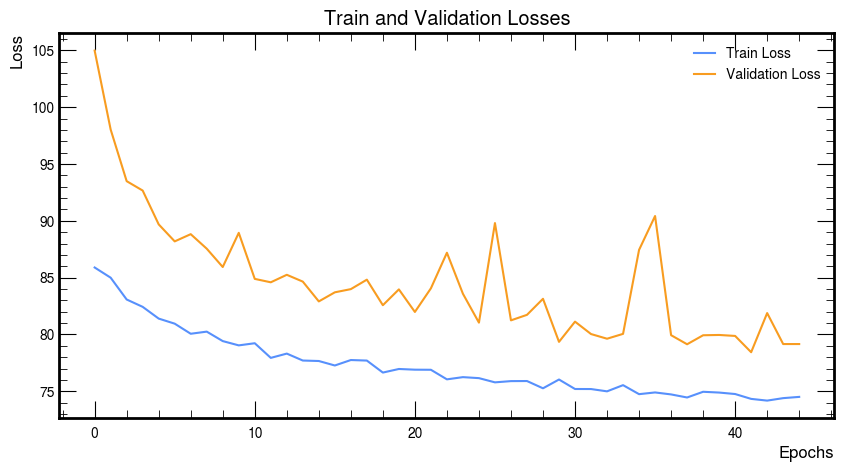

In [209]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses[5:], label='Train Loss')
plt.plot(val_losses[5:], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Train and Validation Losses')
plt.legend()
plt.show()

Amostra do VAE tentando reproduzir o dataset de treino (dados normalizados)

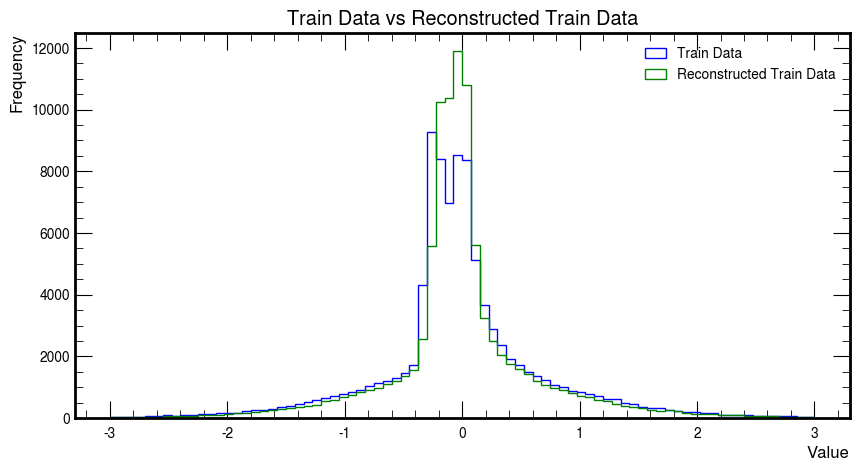

In [210]:
model.eval()
with torch.no_grad():
    recon_train, _, _ = model(normalize(x_train).float())

plt.figure(figsize=(10, 5))
plt.hist(normalize(x_train).cpu().numpy().flatten(), bins=80, range=[-3, 3], histtype='step', color='blue', label='Train Data')
plt.hist(recon_train.cpu().numpy().flatten(), bins=80, range=[-3, 3], histtype='step', color='green', label='Reconstructed Train Data')
plt.title('Train Data vs Reconstructed Train Data')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.legend()
plt.show()


Amostra do VAE tentando reproduzir o dataset de teste (dados normalizados)

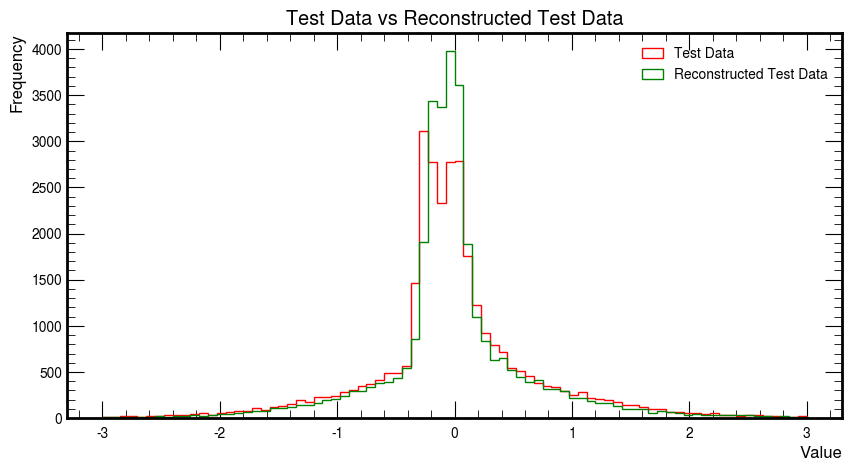

In [211]:
with torch.no_grad():
    recon_test, _, _ = model(normalize(x_test).float())

plt.figure(figsize=(10, 5))
plt.hist(normalize(x_test).cpu().numpy().flatten(), bins=80, range=[-3, 3], histtype='step', color='red', label='Test Data')
plt.hist(recon_test.cpu().numpy().flatten(), bins=80, range=[-3, 3], histtype='step', color='green', label='Reconstructed Test Data')
plt.title('Test Data vs Reconstructed Test Data')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.legend()
plt.show()


Amostra do VAE tentando gerar novos dados que seguem a distribuição do input (dados normalizados)

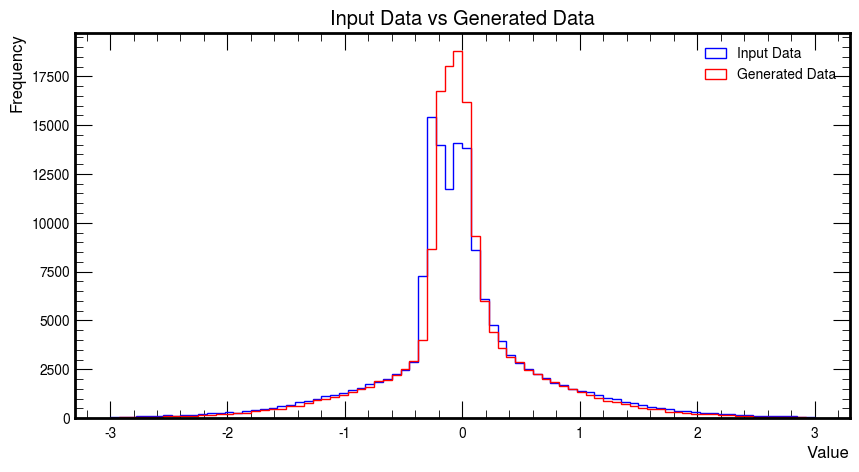

In [212]:
with torch.no_grad():
    z = torch.randn(tensor_data.size(0), best_params['z_dim']).to(device)
    generated_data = model.decoder(z)

plt.figure(figsize=(10, 5))
plt.hist(normalize(tensor_data).cpu().numpy().flatten(), bins=80, range=[-3, 3], histtype='step', color='blue', label='Input Data')
plt.hist(generated_data.cpu().numpy().flatten(), bins=80, range=[-3, 3], histtype='step', color='red', label='Generated Data')
plt.title('Input Data vs Generated Data')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.legend()
plt.show()


In [213]:
import scipy.stats as stats
# Teste de Kolmogorov-Smirnov
train_recon_ks = stats.ks_2samp(x_train.cpu().numpy().flatten(), recon_train.cpu().numpy().flatten())
test_recon_ks = stats.ks_2samp(x_test.cpu().numpy().flatten(), recon_test.cpu().numpy().flatten())
input_generated_ks = stats.ks_2samp(tensor_data.cpu().numpy().flatten(), generated_data.cpu().numpy().flatten())

print(f"KS test for Train vs. Reconstructed Train: statistic={train_recon_ks.statistic}, p-value={train_recon_ks.pvalue}")
print(f"KS test for Test vs. Reconstructed Test: statistic={test_recon_ks.statistic}, p-value={test_recon_ks.pvalue}")
print(f"KS test for Input vs. Generated: statistic={input_generated_ks.statistic}, p-value={input_generated_ks.pvalue}")

KS test for Train vs. Reconstructed Train: statistic=0.34857291666666673, p-value=0.0
KS test for Test vs. Reconstructed Test: statistic=0.34975, p-value=0.0
KS test for Input vs. Generated: statistic=0.34530625000000004, p-value=0.0


Abaixo, iremos desnormalizar os dados para gerar plots com a distribuição original, retomando a problemática da distribuição dos momentos tranversais dos píons e dos kaons.

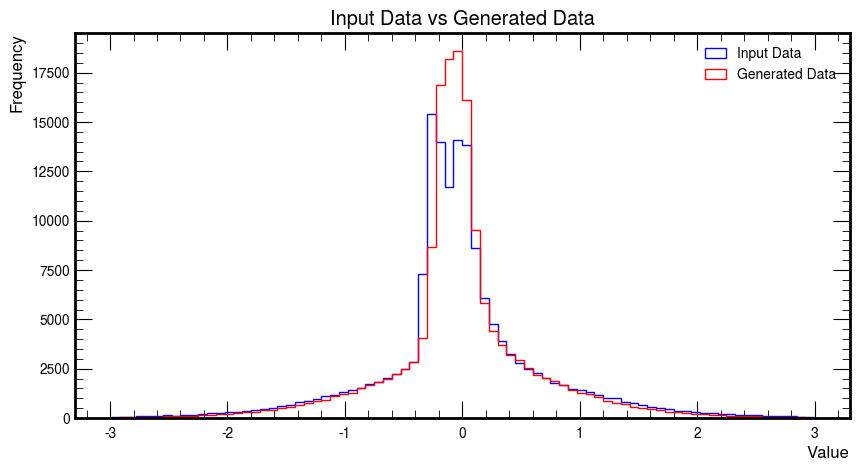

In [214]:
with torch.no_grad():
    z = torch.randn(tensor_data.size(0), best_params['z_dim']).to(device)
    generated_data = model.decoder(z)

plt.figure(figsize=(10, 5))
plt.hist(normalize(tensor_data).cpu().numpy().flatten(), bins=80, range=[-3, 3], histtype='step', color='blue', label='Input Data')
plt.hist(generated_data.cpu().numpy().flatten(), bins=80, range=[-3, 3], histtype='step', color='red', label='Generated Data')
plt.title('Input Data vs Generated Data')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.legend()
plt.show()


Amostra do VAE tentando reproduzir o dataset de treino (dados desnormalizados)

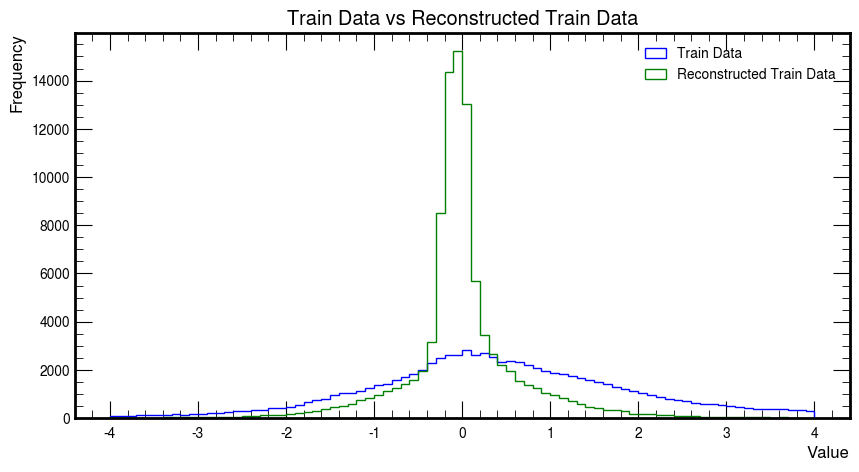

In [215]:
plt.figure(figsize=(10, 5))
plt.hist(x_train.cpu().numpy().flatten(), bins=80, range=[-4, 4], histtype='step', color='blue', label='Train Data')
plt.hist(recon_train.cpu().numpy().flatten(), bins=80, range=[-4, 4], histtype='step', color='green', label='Reconstructed Train Data')
plt.title('Train Data vs Reconstructed Train Data')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.legend()
plt.show()

Amostra do VAE tentando reproduzir o dataset de teste (dados desnormalizados)

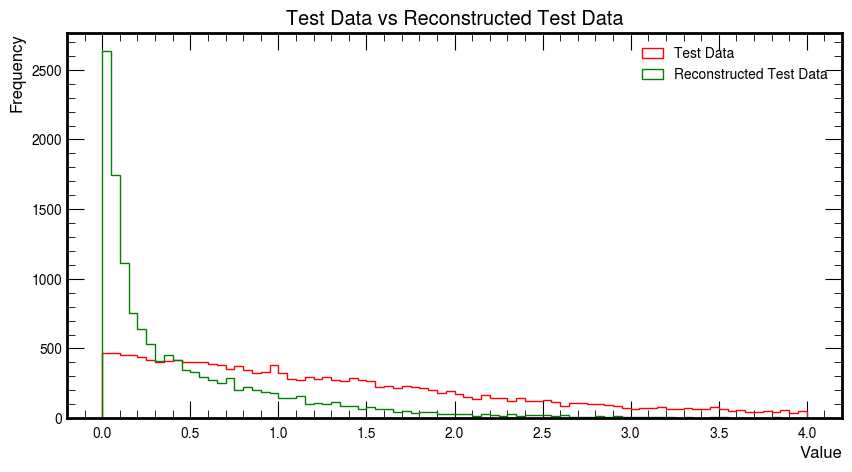

In [216]:
plt.figure(figsize=(10, 5))
plt.hist(x_test.cpu().numpy().flatten(), bins=80, range=[0, 4], histtype='step', color='red', label='Test Data')
plt.hist(recon_test.cpu().numpy().flatten(), bins=80, range=[0, 4], histtype='step', color='green', label='Reconstructed Test Data')
plt.title('Test Data vs Reconstructed Test Data')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.legend()
plt.show()

Amostra do VAE tentando gerar novos dados que seguem a mesma distribuição do input (dados desnormalizados)

In [217]:
# PLOTS FUNCTION

def subplot_trk(data, generated, trk):
    if trk == "trk1":
        id_list = [0, 2, 4, 6]
        name_list = ["Kaons x component momentum (Px)", "Kaons y component momentum (Py)", "Kaons z component momentum (Pz)", "Kaons energy (E)"]
    if trk == "trk2":
        id_list = [1, 3, 5, 7]
        name_list = ["Pions x component momentum (Px)", "Pions y component momentum (Py)", "Pions z component momentum (Pz)", "Pions energy (E)"]
    if trk == "both":
        data_tensor = torch.zeros([2*data.size()[0], 4])
        gen_tensor = torch.zeros([2*data.size()[0], 4])
        data_tensor[:, 0], gen_tensor[:, 0] = data[:, :2].flatten(), generated[:, :2].flatten()
        data_tensor[:, 1], gen_tensor[:, 1] = data[:, 2:4].flatten(), generated[:, 2:4].flatten()
        data_tensor[:, 2], gen_tensor[:, 2] = data[:, 4:6].flatten(), generated[:, 4:6].flatten()
        data_tensor[:, 3], gen_tensor[:, 3] = data[:, 6:8].flatten(), generated[:, 6:8].flatten()
        data, generated = data_tensor, gen_tensor
        id_list = [0, 1, 2, 3]
        name_list = ["Px1+Px2", "Py1+Py2", "Pz1+Pz2", "E1+E2"]
        
    range_list = [[-5, 5], [-5, 5], [-10, 10], [0, 20]]
    
    plt.figure(figsize=(10,10))
    for i in range(len(id_list)):
        plt.subplot(2, 2, i+1)
        plt.hist(data[:, id_list[i]].numpy().flatten(), bins=80, range=range_list[i], histtype='step', color='blue', label='Input Data')
        plt.hist(generated[:, id_list[i]].numpy().flatten(), bins=80, range=range_list[i], histtype='step', color='red', label='Generated Data')
        plt.title(f'{name_list[i]}')
        plt.xlabel('Value')
        plt.ylabel('Frequency')
        plt.legend()

    return plt.show()

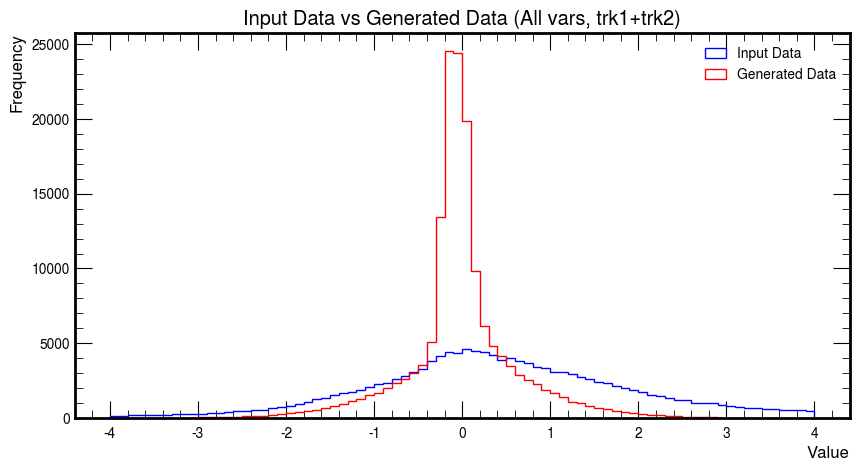

torch.Size([20000, 8])


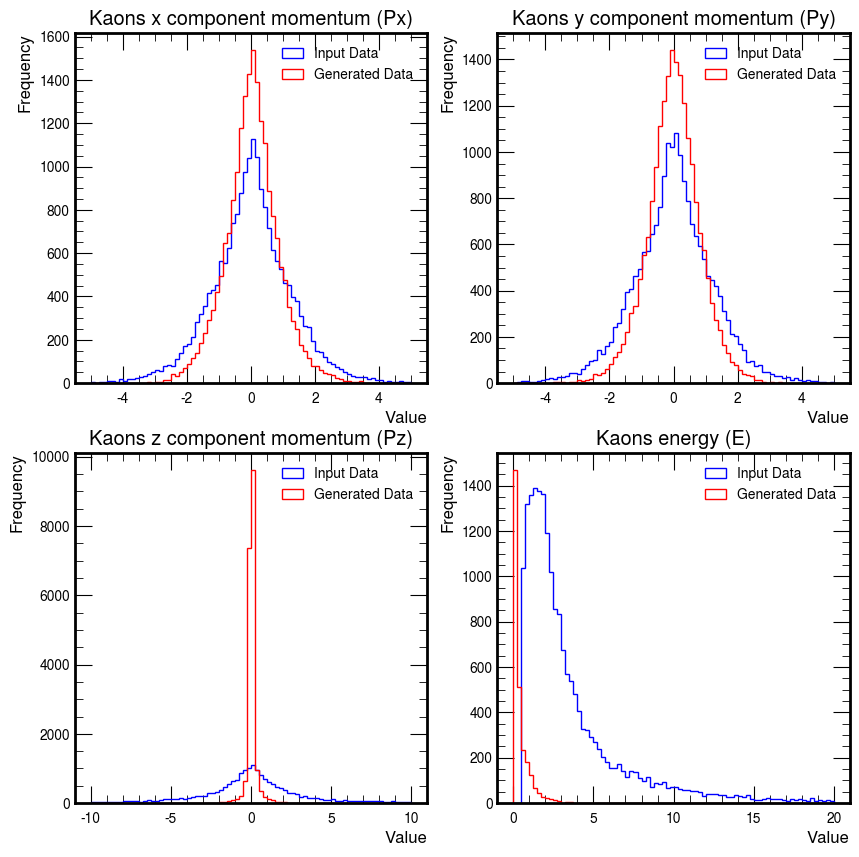

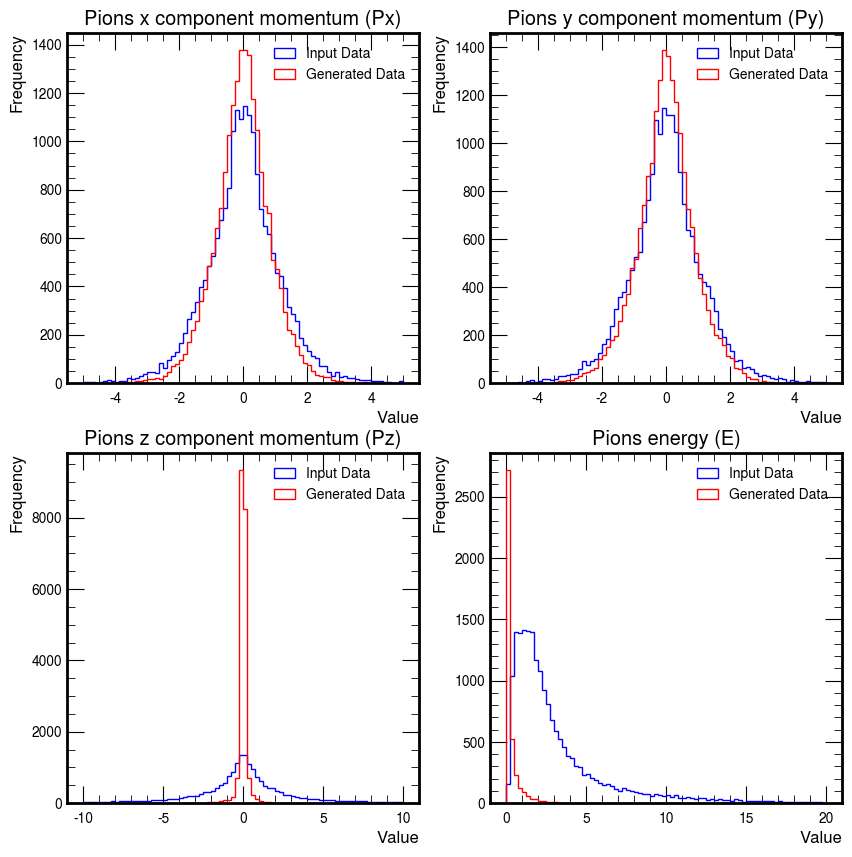

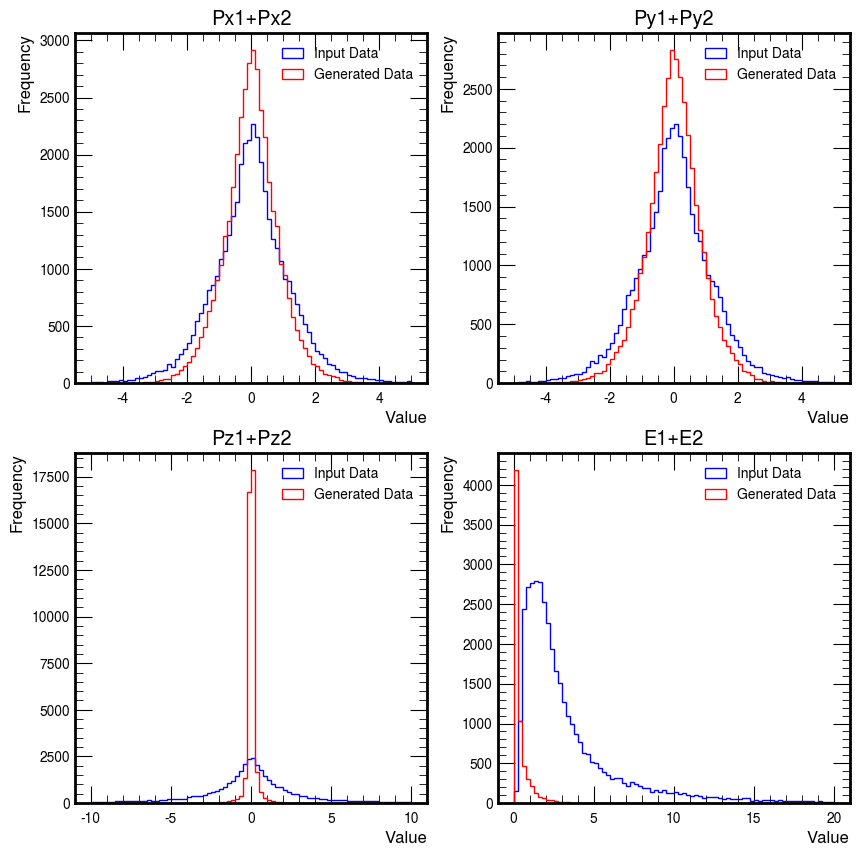

In [218]:
plt.figure(figsize=(10, 5))
plt.hist(tensor_data.cpu().flatten(), bins=80, range=[-4, 4], histtype='step', color='blue', label='Input Data')
plt.hist(generated_data.cpu().flatten(), bins=80, range=[-4, 4], histtype='step', color='red', label='Generated Data')
plt.title('Input Data vs Generated Data (All vars, trk1+trk2)')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.legend()
plt.show()

print(tensor_data.size())
subplot_trk(tensor_data.cpu(), generated_data.cpu(), "trk1")
subplot_trk(tensor_data.cpu(), generated_data.cpu(), "trk2")
subplot_trk(tensor_data.cpu(), generated_data.cpu(), "both")

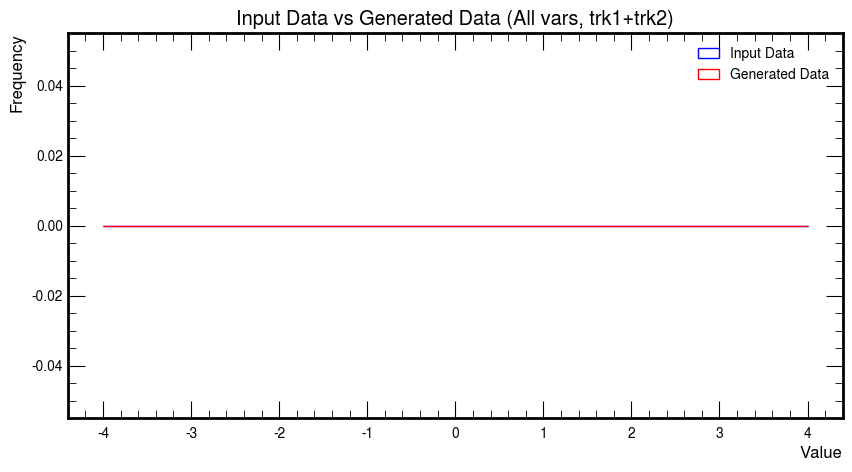

torch.Size([0, 8])


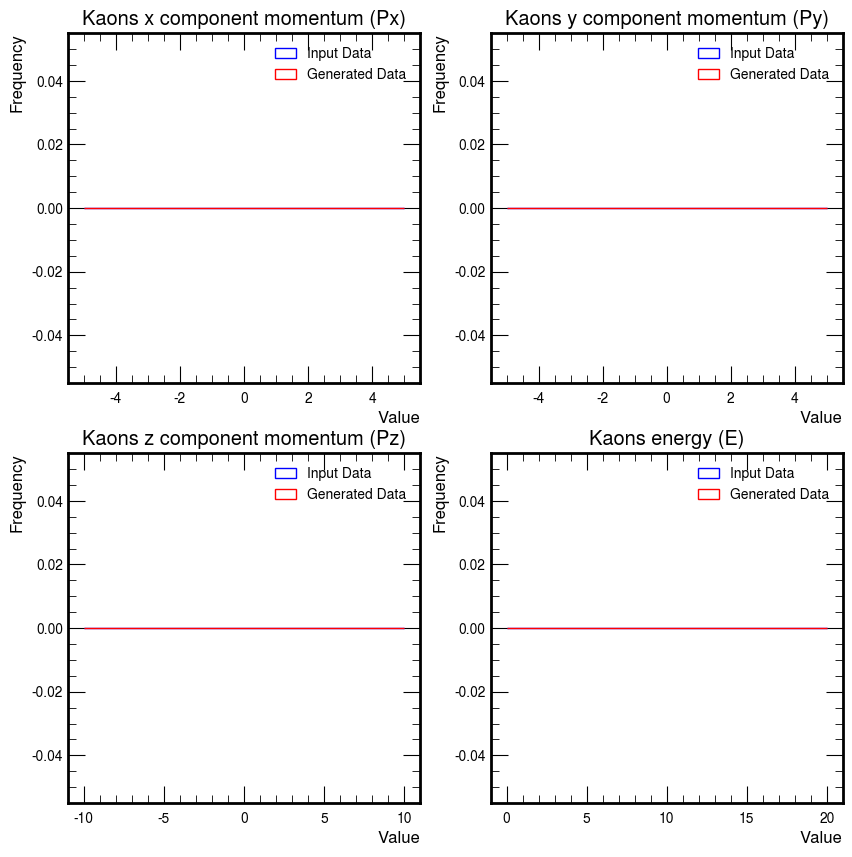

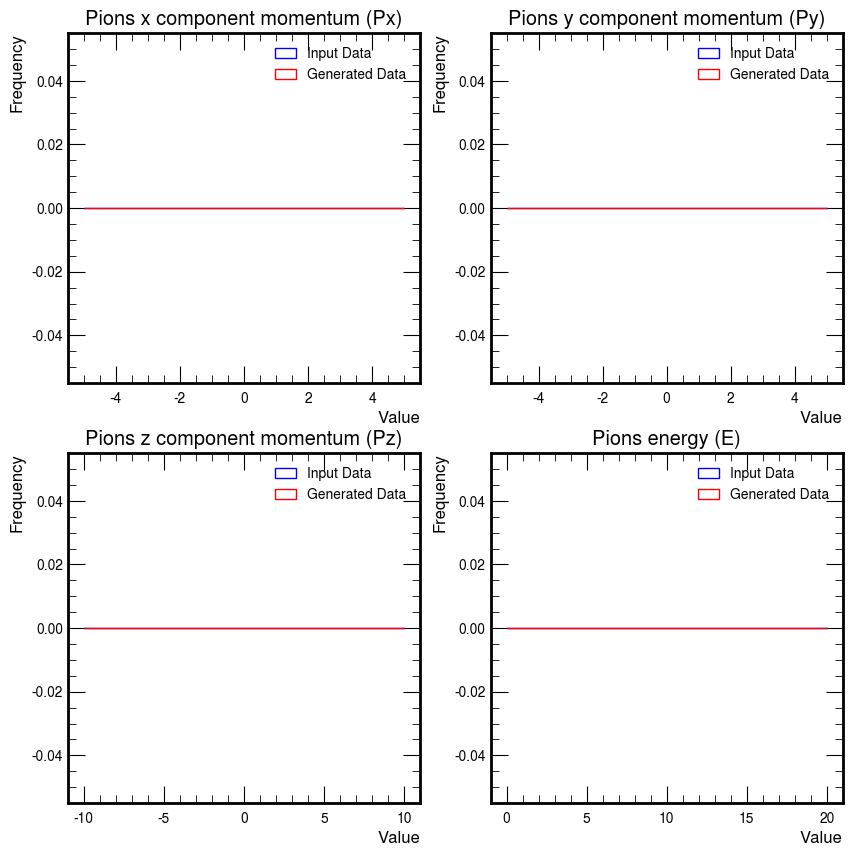

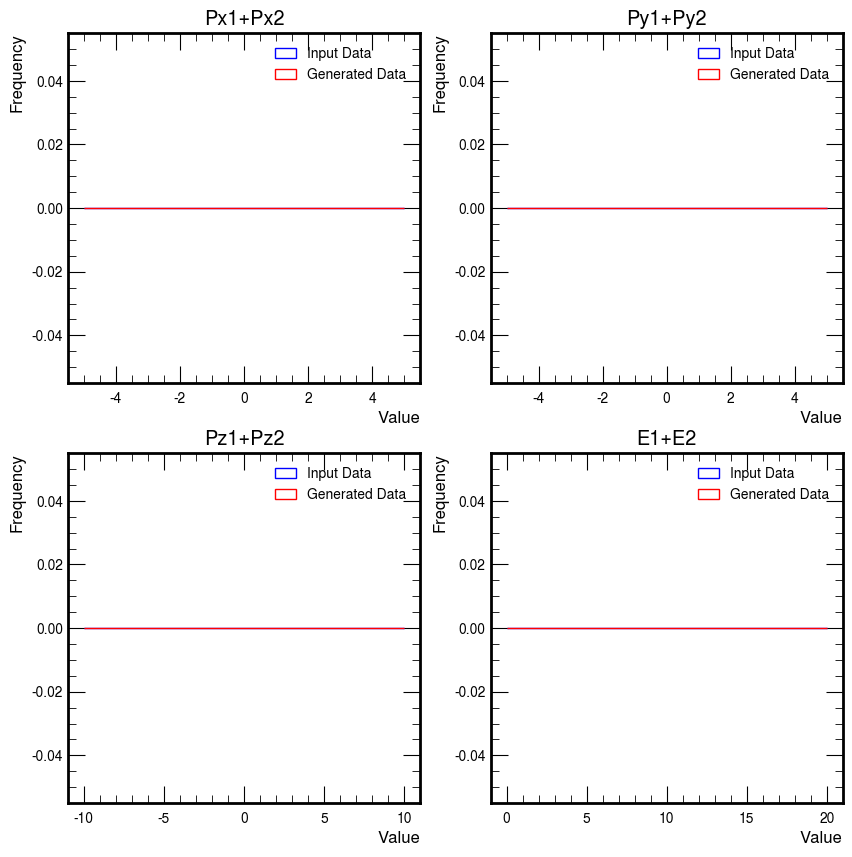

In [219]:

generated_px = generated_data[:, 0] + generated_data[:, 1]
generated_py = generated_data[:, 2] + generated_data[:, 3]
generated_pz = generated_data[:, 4] + generated_data[:, 5]
generated_E = generated_data[:, 6] + generated_data[:, 7]

mass_mask = (torch.sqrt(generated_E**2 - generated_px**2 - generated_py**2 - generated_pz**2) > 0)
energies_mask = ((generated_data[:, 6] > 0) & (generated_data[:, 7] > 0))
physical_mask = (mass_mask & energies_mask)
filtered_generated_data = generated_data[physical_mask]
filtered_tensor_data = tensor_data[physical_mask]

plt.figure(figsize=(10, 5))
plt.hist(filtered_tensor_data.cpu().flatten(), bins=80, range=[-4, 4], histtype='step', color='blue', label='Input Data')
plt.hist(filtered_generated_data.cpu().flatten(), bins=80, range=[-4, 4], histtype='step', color='red', label='Generated Data')
plt.title('Input Data vs Generated Data (All vars, trk1+trk2)')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.legend()
plt.show()

print(filtered_tensor_data.size())
subplot_trk(filtered_tensor_data.cpu(), filtered_generated_data.cpu(), "trk1")
subplot_trk(filtered_tensor_data.cpu(), filtered_generated_data.cpu(), "trk2")
subplot_trk(filtered_tensor_data.cpu(), filtered_generated_data.cpu(), "both")

Abaixo, é rodado um teste de Kolmogorov-Smirnov para analisar a proximidade dos dois hitogramas em cada gráfico (apenas para as distribuições desnormalizadas). Uma das métricas de interesse é o p-valor.

P-Valor Significativo: um p-valor abaixo de 0.05 é frequentemente considerado significativo, o que indica que a hipótese nula (de que as distribuições são iguais) pode ser rejeitada.

P-Valor Não Significativo: Um p-valor acima de 0.05 geralmente sugere que não há evidência suficiente para rejeitar a hipótese nula. Valores como 0.10, 0.15, ou mais altos são interpretados como indicando uma falta de diferença significativa entre as distribuições.

P-Valor > 0.05: Indica que não há uma diferença significativa entre as distribuições comparadas. Esse é um bom sinal, sugerindo que as distribuições dos dados gerados ou reconstruídos são semelhantes aos dados reais.

P-Valor > 0.10 ou 0.15: Indica uma forte semelhança entre as distribuições, o que é ótimo.

In [220]:
import scipy.stats as stats
# Teste de Kolmogorov-Smirnov
train_recon_ks = stats.ks_2samp(x_train.cpu().flatten(), recon_train.cpu().flatten())
test_recon_ks = stats.ks_2samp(x_test.cpu().flatten(), recon_test.cpu().flatten())
input_generated_ks = stats.ks_2samp(tensor_data.cpu().flatten(), generated_data.cpu().flatten())

print(f"KS test for Train vs. Reconstructed Train: statistic={train_recon_ks.statistic}, p-value={train_recon_ks.pvalue}")
print(f"KS test for Test vs. Reconstructed Test: statistic={test_recon_ks.statistic}, p-value={test_recon_ks.pvalue}")
print(f"KS test for Input vs. Generated: statistic={input_generated_ks.statistic}, p-value={input_generated_ks.pvalue}")

KS test for Train vs. Reconstructed Train: statistic=0.34857291666666673, p-value=0.0
KS test for Test vs. Reconstructed Test: statistic=0.34975, p-value=0.0
KS test for Input vs. Generated: statistic=0.3467187500000001, p-value=0.0


In [221]:
print(mass_func(filtered_generated_data).mean())

tensor(nan, device='cuda:0')


In [222]:
wasserstein_distance(normalize(tensor_data).cpu().numpy().flatten(), generated_data.cpu().numpy().flatten())

np.float64(0.1189746405272572)